# Exploratory Data Analysis (EDA)
## Dataset: application_train

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This project focuses on performing a comprehensive Exploratory Data Analysis (EDA) on the `application_train` dataset from the Home Credit risk modeling case. The goal is to understand the underlying patterns, data quality, and key drivers related to loan default behavior.

---

## 🎯 Objectives
- Understand the structure and characteristics of the dataset  
- Identify data quality issues (missing values, outliers, inconsistencies)  
- Analyze the distribution of key variables  
- Explore relationships between features and the target variable (loan default)  
- Generate initial insights to support feature engineering and modeling  

---

## 🔍 Analysis Scope
The analysis includes:
- Univariate analysis (distribution of individual variables)  
- Bivariate analysis (relationship with TARGET)  
- Identification of class imbalance  
- Detection of anomalies and outliers  
- Initial business-driven interpretation of features  

---

## 🧠 Key Questions
- What factors differentiate default vs non-default customers?  
- How is income related to credit amount and repayment behavior?  
- Are there strong predictors within external scores (EXT_SOURCE)?  
- What patterns exist in demographic and financial features?  

---

## 🛠 Tools & Libraries
- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  

---

## 📊 Output
The output of this EDA will serve as:
- A foundation for feature engineering  
- Input for credit scoring models  
- Business insights for risk assessment  

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset application_train
application_train = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train)

# 1. About Dataset

Dataset terdiri dari **307,511 observasi** dan **122 fitur**, yang merepresentasikan data aplikasi kredit individu. Setiap baris menggambarkan satu nasabah beserta karakteristik finansial, demografis, dan informasi pendukung lainnya.

Fitur dalam dataset dapat dikelompokkan menjadi:
- **Target variable**: `TARGET`, yang menunjukkan status gagal bayar  
- **Numerical features**: mencakup informasi keuangan, waktu, dan variabel kuantitatif lainnya  
- **Categorical features**: seperti jenis pekerjaan, status keluarga, dan tipe kontrak  
- **Binary indicators**: flag kepemilikan aset dan kelengkapan dokumen  

Selain itu, terdapat fitur dengan suffix `_AVG`, `_MEDI`, dan `_MODE` yang merepresentasikan **karakteristik lingkungan tempat tinggal nasabah**, seperti kondisi bangunan dan fasilitas, dalam bentuk agregasi statistik.

In [4]:
df_app_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

# 2. Target Distribution

## 2.1 Default Rate

Distribusi target menunjukkan bahwa mayoritas nasabah **tidak mengalami gagal bayar (non-default)**.

- Total non-default (`TARGET = 0`): 282,686 (~91.9%)
- Total default (`TARGET = 1`): 24,825 (~8.1%)

Hal ini mengindikasikan bahwa dataset bersifat **imbalanced**, di mana jumlah nasabah yang default jauh lebih sedikit dibandingkan yang tidak default. Kondisi ini perlu diperhatikan pada tahap modeling, terutama dalam pemilihan metrik evaluasi dan teknik penanganan imbalance.

---

In [5]:
df_app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

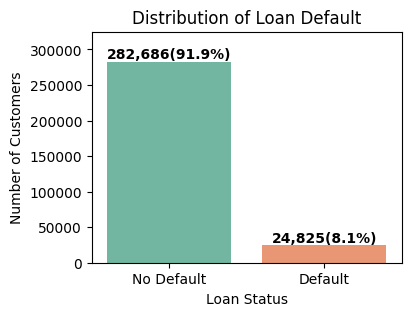

In [6]:
# Plot Loan Distribution
target_df = (
    df_app_train['TARGET']
    .value_counts()
    .rename_axis('Target')
    .reset_index(name='Count')
)
# Percentage
target_df['Percentage'] = target_df['Count'] / target_df['Count'].sum() * 100
# Mapping String
target_df['Target'] = target_df['Target'].map({0: 'No Default', 1: 'Default'})

# Plot
plt.figure(figsize=(4,3))
ax=sns.barplot(
    data=target_df,x='Target',y='Count',
    hue='Target',palette='Set2',legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Loan Default')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')

# Add labels
for i, row in target_df.iterrows():
    ax.text(i,
        row['Count'],f"{row['Count']:,}({row['Percentage']:.1f}%)",
        ha='center',va='bottom', fontweight='bold'
    )

plt.show()

## 2.2 Contract Type

Terdapat dua jenis kontrak dalam dataset:

- **Cash loans**: 278,232 (~90.5%)
- **Revolving loans**: 29,279 (~9.5%)

Mayoritas nasabah menggunakan **cash loans**, yang menunjukkan bahwa tipe pinjaman ini merupakan produk utama dalam dataset. Perbedaan distribusi ini berpotensi mempengaruhi pola risiko kredit, sehingga perlu dianalisis lebih lanjut terhadap hubungannya dengan default rate.

---

In [7]:
df_app_train['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

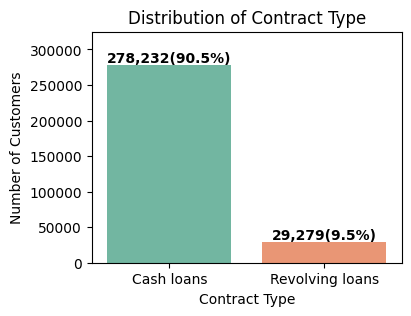

In [8]:
# Plot COntract Type
contract_df = (
    df_app_train['NAME_CONTRACT_TYPE']
    .value_counts()
    .rename_axis('CONTRACT TYPE')
    .reset_index(name='Count')
)
# Percentage
contract_df['Percentage'] = contract_df['Count'] / contract_df['Count'].sum() * 100

# Plot
plt.figure(figsize=(4,3))
ax=sns.barplot(
    data=contract_df,x='CONTRACT TYPE',y='Count',
    hue='CONTRACT TYPE',palette='Set2',legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# Add labels
for i, row in contract_df.iterrows():
    ax.text(i,
        row['Count'],f"{row['Count']:,}({row['Percentage']:.1f}%)",
        ha='center',va='bottom', fontweight='bold'
    )

plt.show()

# 3. Missing Value Analysis

Analisis missing value dilakukan untuk memahami kualitas data serta mengidentifikasi potensi informasi yang terkandung dalam data yang hilang.

Pendekatan yang digunakan dalam analisis ini meliputi:

- **Mengukur** jumlah dan persentase missing value pada setiap fitur  
- **Mengelompokkan** fitur berdasarkan tingkat missing  
- **Mengevaluasi** hubungan antara missing value dengan *default rate*  

Hasil dari analisis ini digunakan sebagai dasar dalam menentukan strategi penanganan data, yaitu:

- **Penghapusan fitur** dengan tingkat missing yang sangat tinggi dan tidak informatif  
- **Imputasi nilai** pada fitur dengan missing moderat  
- **Penambahan missing indicator** untuk menangkap pola risiko dari data yang hilang  

## 3.1 Missing Values Count

In [ ]:
# Missing Value Percentage + Category
missing_df = (
    df_app_train.isnull()
    .agg(['sum', 'mean'])
    .T
    .reset_index()
    .rename(columns={
        'index': 'Feature',
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
)

# Convert to percentage
missing_df['Missing_Percentage'] = (missing_df['Missing_Percentage'] * 100).round(2)

# Add Category
missing_df['Category'] = pd.cut(
    missing_df['Missing_Percentage'],
    bins=[-1, 20, 50, 100],
    labels=['Low (<20%)', 'Medium (20–50%)', 'High (>50%)']
)

# Add Data Type
missing_df['Data_Type'] = missing_df['Feature'].map(df_app_train.dtypes)

# Sort
missing_df = missing_df.sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing_df

,Feature,Missing_Count,Missing_Percentage,Category,Data_Type
48,COMMONAREA_AVG,214865.0,69.87,High (>50%),float64
62,COMMONAREA_MODE,214865.0,69.87,High (>50%),float64
76,COMMONAREA_MEDI,214865.0,69.87,High (>50%),float64
56,NONLIVINGAPARTMENTS_AVG,213514.0,69.43,High (>50%),float64
70,NONLIVINGAPARTMENTS_MODE,213514.0,69.43,High (>50%),float64
84,NONLIVINGAPARTMENTS_MEDI,213514.0,69.43,High (>50%),float64
86,FONDKAPREMONT_MODE,210295.0,68.39,High (>50%),str
68,LIVINGAPARTMENTS_MODE,210199.0,68.35,High (>50%),float64
54,LIVINGAPARTMENTS_AVG,210199.0,68.35,High (>50%),float64
82,LIVINGAPARTMENTS_MEDI,210199.0,68.35,High (>50%),float64


## 3.2 Feature With >50% Missing Values

In [50]:
# Default Rate
missing_analysis_df = pd.DataFrame({
    col: df_app_train.groupby(f'{col}_MISSING')['TARGET'].mean()
    for col in high_missing_features
}).T

# Convert to percentage
missing_analysis_df = (missing_analysis_df * 100).round(2)

# Rename columns
missing_analysis_df = missing_analysis_df.rename(columns={
    0: 'Default Rate (Not Missing) (%)',
    1: 'Default Rate (Missing) (%)'
})

# Rename index
missing_analysis_df.index.name = 'Features'
missing_analysis_df

,Default Rate (Not Missing) (%),Default Rate (Missing) (%)
Features,,
COMMONAREA_AVG,6.91,8.57
COMMONAREA_MODE,6.91,8.57
COMMONAREA_MEDI,6.91,8.57
NONLIVINGAPARTMENTS_AVG,6.91,8.58
NONLIVINGAPARTMENTS_MODE,6.91,8.58
NONLIVINGAPARTMENTS_MEDI,6.91,8.58
FONDKAPREMONT_MODE,6.89,8.62
LIVINGAPARTMENTS_MODE,6.89,8.62
LIVINGAPARTMENTS_AVG,6.89,8.62


## 3.3 Features With 20-50% Missing Value

In [51]:
# Features with 20%–50% missing values
medium_missing_features = missing_df.loc[
    (missing_df['Missing_Percentage'] >= 20) & 
    (missing_df['Missing_Percentage'] <= 50),
    'Feature'
].tolist()


# Create missing indicator
for col in medium_missing_features:
    df_app_train[f'{col}_MISSING'] = df_app_train[col].isnull().astype(int)


# Default rate
medium_missing_analysis = pd.DataFrame({
    col: df_app_train.groupby(f'{col}_MISSING')['TARGET'].mean()
    for col in medium_missing_features
}).T

# Convert ke persen
medium_missing_analysis = (medium_missing_analysis * 100).round(2)

# Rename columns
medium_missing_analysis = medium_missing_analysis.rename(columns={
    0: 'Default Rate (Not Missing) (%)',
    1: 'Default Rate (Missing) (%)'
})

# Rename index
medium_missing_analysis.index.name = 'Features'
medium_missing_analysis

,Default Rate (Not Missing) (%),Default Rate (Missing) (%)
Features,,
FLOORSMAX_MODE,6.97,9.19
FLOORSMAX_AVG,6.97,9.19
FLOORSMAX_MEDI,6.97,9.19
YEARS_BEGINEXPLUATATION_MEDI,6.99,9.20
YEARS_BEGINEXPLUATATION_AVG,6.99,9.20
YEARS_BEGINEXPLUATATION_MODE,6.99,9.20
TOTALAREA_MODE,6.99,9.23
EMERGENCYSTATE_MODE,7.00,9.26
OCCUPATION_TYPE,8.79,6.51
